## TEXT CLASSIFICATION USING NAIVE BAYES AND SENTIMENT ANALYSIS ON BLOG POSTS

#### 1. Data Exploration & Preprocessing

In [13]:
import pandas as pd
import re
import nltk
from nltk.corpus import stopwords

nltk.download('stopwords')

# Load dataset
df = pd.read_csv(r'C:\Users\suraj\OneDrive\Desktop\data sets\blogs (1).csv')

print(df.head())
print(df.columns)
print(df['Labels'].value_counts())

# Text cleaning function
stop_words = set(stopwords.words('english'))

def clean_text(text):
    text = text.lower()
    text = re.sub(r'[^a-zA-Z]', ' ', text)  # remove punctuation
    words = text.split()
    words = [w for w in words if w not in stop_words]
    return " ".join(words)

# Apply cleaning
df['clean_text'] = df['Data'].apply(clean_text)
print(df[['Data','clean_text']].head())

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\suraj\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


                                                Data       Labels
0  Path: cantaloupe.srv.cs.cmu.edu!magnesium.club...  alt.atheism
1  Newsgroups: alt.atheism\nPath: cantaloupe.srv....  alt.atheism
2  Path: cantaloupe.srv.cs.cmu.edu!das-news.harva...  alt.atheism
3  Path: cantaloupe.srv.cs.cmu.edu!magnesium.club...  alt.atheism
4  Xref: cantaloupe.srv.cs.cmu.edu alt.atheism:53...  alt.atheism
Index(['Data', 'Labels'], dtype='object')
Labels
alt.atheism                 100
comp.graphics               100
talk.politics.misc          100
talk.politics.mideast       100
talk.politics.guns          100
soc.religion.christian      100
sci.space                   100
sci.med                     100
sci.electronics             100
sci.crypt                   100
rec.sport.hockey            100
rec.sport.baseball          100
rec.motorcycles             100
rec.autos                   100
misc.forsale                100
comp.windows.x              100
comp.sys.mac.hardware       100
comp.sys.ib

#### 2. Feature Extraction

In [14]:
from sklearn.feature_extraction.text import TfidfVectorizer

tfidf = TfidfVectorizer(max_features=5000)

X = tfidf.fit_transform(df['clean_text'])
y = df['Labels']

#### 3. Train-Test Split

In [15]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

#### 4. Naive Bayes Model

In [16]:
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import accuracy_score, classification_report

model = MultinomialNB()
model.fit(X_train, y_train)

y_pred = model.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))

Accuracy: 0.8275
                          precision    recall  f1-score   support

             alt.atheism       0.80      0.60      0.69        20
           comp.graphics       0.74      0.85      0.79        20
 comp.os.ms-windows.misc       0.80      1.00      0.89        20
comp.sys.ibm.pc.hardware       0.68      0.85      0.76        20
   comp.sys.mac.hardware       0.94      0.75      0.83        20
          comp.windows.x       0.87      0.65      0.74        20
            misc.forsale       0.86      0.90      0.88        20
               rec.autos       0.80      1.00      0.89        20
         rec.motorcycles       0.89      0.80      0.84        20
      rec.sport.baseball       0.95      0.90      0.92        20
        rec.sport.hockey       0.87      1.00      0.93        20
               sci.crypt       0.95      1.00      0.98        20
         sci.electronics       0.87      0.65      0.74        20
                 sci.med       0.94      0.80      0.86   

#### 5. Sentiment Analysis

In [17]:
pip install textblob

Note: you may need to restart the kernel to use updated packages.


In [18]:
from textblob import TextBlob

def get_sentiment(text):
    polarity = TextBlob(text).sentiment.polarity
    if polarity > 0:
        return "Positive"
    elif polarity < 0:
        return "Negative"
    else:
        return "Neutral"

# Apply sentiment analysis
df['Sentiment'] = df['Data'].apply(get_sentiment)

print(df[['Data','Sentiment']].head())

                                                Data Sentiment
0  Path: cantaloupe.srv.cs.cmu.edu!magnesium.club...  Positive
1  Newsgroups: alt.atheism\nPath: cantaloupe.srv....  Negative
2  Path: cantaloupe.srv.cs.cmu.edu!das-news.harva...  Positive
3  Path: cantaloupe.srv.cs.cmu.edu!magnesium.club...  Positive
4  Xref: cantaloupe.srv.cs.cmu.edu alt.atheism:53...  Positive


#### 6. Sentiment Distribution

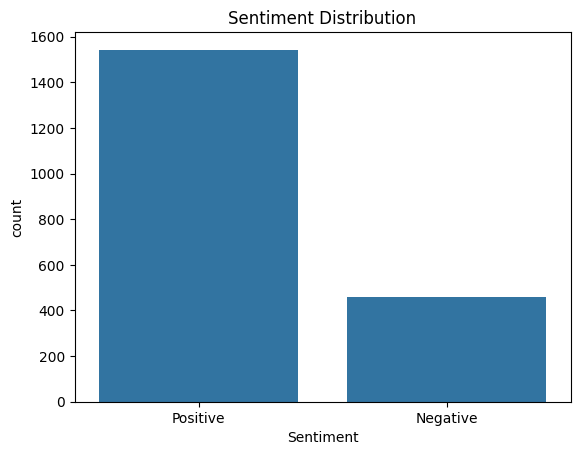

In [19]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.countplot(x=df['Sentiment'])
plt.title("Sentiment Distribution")
plt.show()

#### 7. Sentiment vs Category

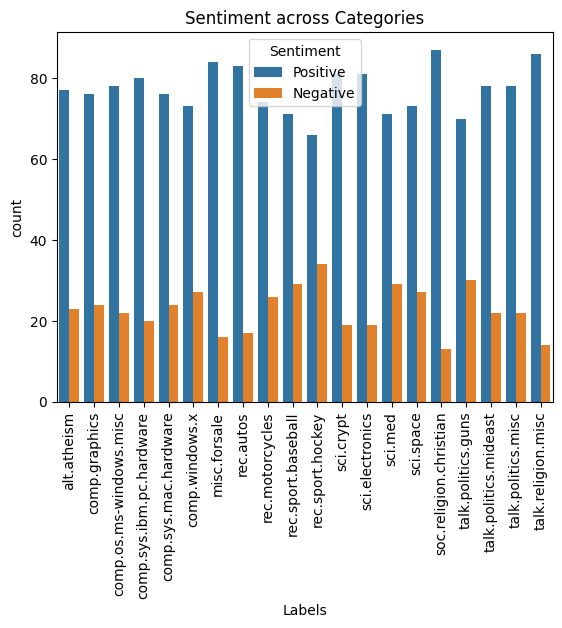

In [20]:
import seaborn as sns
sns.countplot(x='Labels', hue='Sentiment', data=df)
plt.xticks(rotation=90)
plt.title("Sentiment across Categories")
plt.show()

#### 8. Explanation

Preprocessing:
Converted text to lowercase
Removed punctuation and stopwords
Cleaned text improves model accuracy
1.Feature Extraction:
Used TF-IDF to convert text → numerical features
2.Model:
Used Multinomial Naive Bayes
Works well for text classification
3.Evaluation:
Accuracy, Precision, Recall, F1-score used
4.Sentiment Analysis:
Classified blogs into:
Positive
Negative
Neutral